<a href="https://colab.research.google.com/github/Rini43/Asteroid_Diameter_Prediction/blob/main/exit_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Asteroides Diameter Predictor

# Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import os

# Read the data

In [64]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
# filepath to the .excel file
# Load the dataset from the cloned GitHub repository

filepath = '/content/drive/MyDrive/Data/dataset.csv'
df_asteroid = pd.read_csv(filepath)
df_asteroid.head(20)

/tmp/ipykernel_859/4088132661.py:5: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_asteroid = pd.read_csv(filepath)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
5,a0000006,2000006,6 Hebe,6,Hebe,NaN,N,N,5.80,185.180,...,2.191800e-06,1.122100e-05,1.300600e-05,7.392200e-06,3.306700e-09,4.438800e-10,2.875400e-05,2.344500e-06,MBA,0.41032
6,a0000007,2000007,7 Iris,7,Iris,NaN,N,N,5.60,199.830,...,2.582500e-06,2.641200e-05,2.707500e-05,7.014700e-06,2.469500e-09,3.370100e-10,2.662700e-05,1.699400e-06,MBA,0.38128
7,a0000008,2000008,8 Flora,8,Flora,NaN,N,N,6.50,147.491,...,3.240300e-06,2.432000e-05,2.664600e-05,1.209200e-05,2.668100e-09,4.746200e-10,4.018700e-05,1.876500e-06,MBA,0.54186
8,a0000009,2000009,9 Metis,9,Metis,NaN,N,N,6.30,190.000,...,2.007400e-06,2.417000e-05,2.600800e-05,1.036600e-05,3.470200e-09,5.192700e-10,3.870700e-05,2.614600e-06,MBA,0.44895
9,a0000010,2000010,10 Hygiea,10,Hygiea,NaN,N,N,5.50,407.120,...,2.173400e-06,2.855200e-05,3.023700e-05,1.124600e-05,7.699800e-09,5.847400e-10,6.482900e-05,6.724400e-06,MBA,0.53434


In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## EDA

In [67]:
# Identifying numerical and categorical data
df_asteroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [68]:
# Identifying dataset size
df_asteroid.shape

(958524, 45)

In [69]:
# Statistical Summary
df_asteroid.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [70]:
df_asteroid.columns.tolist()

['id',
 'spkid',
 'full_name',
 'pdes',
 'name',
 'prefix',
 'neo',
 'pha',
 'H',
 'diameter',
 'albedo',
 'diameter_sigma',
 'orbit_id',
 'epoch',
 'epoch_mjd',
 'epoch_cal',
 'equinox',
 'e',
 'a',
 'q',
 'i',
 'om',
 'w',
 'ma',
 'ad',
 'n',
 'tp',
 'tp_cal',
 'per',
 'per_y',
 'moid',
 'moid_ld',
 'sigma_e',
 'sigma_a',
 'sigma_q',
 'sigma_i',
 'sigma_om',
 'sigma_w',
 'sigma_ma',
 'sigma_ad',
 'sigma_n',
 'sigma_tp',
 'sigma_per',
 'class',
 'rms']

In [71]:
df_asteroid.dtypes

,0
id,object
spkid,int64
full_name,object
pdes,object
name,object
prefix,object
neo,object
pha,object
H,float64
diameter,float64


### MIssing Values

In [72]:
# Trying to findout if there is any missing value present
df_asteroid.isna().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


In [73]:
# Checking the missing percentage

df_asteroid.isna().mean() * 100

,0
id,0.000000
spkid,0.000000
full_name,0.000000
pdes,0.000000
name,97.698128
prefix,99.998122
neo,0.000417
pha,2.078300
H,0.653400
diameter,85.789714


### Duplicated Columns

In [74]:
df_asteroid.duplicated().sum()

np.int64(0)

In [75]:
df_asteroid.columns.tolist()

['id',
 'spkid',
 'full_name',
 'pdes',
 'name',
 'prefix',
 'neo',
 'pha',
 'H',
 'diameter',
 'albedo',
 'diameter_sigma',
 'orbit_id',
 'epoch',
 'epoch_mjd',
 'epoch_cal',
 'equinox',
 'e',
 'a',
 'q',
 'i',
 'om',
 'w',
 'ma',
 'ad',
 'n',
 'tp',
 'tp_cal',
 'per',
 'per_y',
 'moid',
 'moid_ld',
 'sigma_e',
 'sigma_a',
 'sigma_q',
 'sigma_i',
 'sigma_om',
 'sigma_w',
 'sigma_ma',
 'sigma_ad',
 'sigma_n',
 'sigma_tp',
 'sigma_per',
 'class',
 'rms']

In [76]:
# Work on diameter data only
df_diameter = df_asteroid[df_asteroid['diameter'].notna()].copy()

print("Total rows:", len(df_asteroid))
print("Rows with diameter:", len(df_diameter))
print("Missing diameter:", df_asteroid['diameter'].isna().sum())
print(df_diameter['diameter'].describe())

Total rows: 958524
Rows with diameter: 136209
Missing diameter: 822315
count    136209.000000
mean          5.506429
std           9.425164
min           0.002500
25%           2.780000
50%           3.972000
75%           5.765000
max         939.400000
Name: diameter, dtype: float64


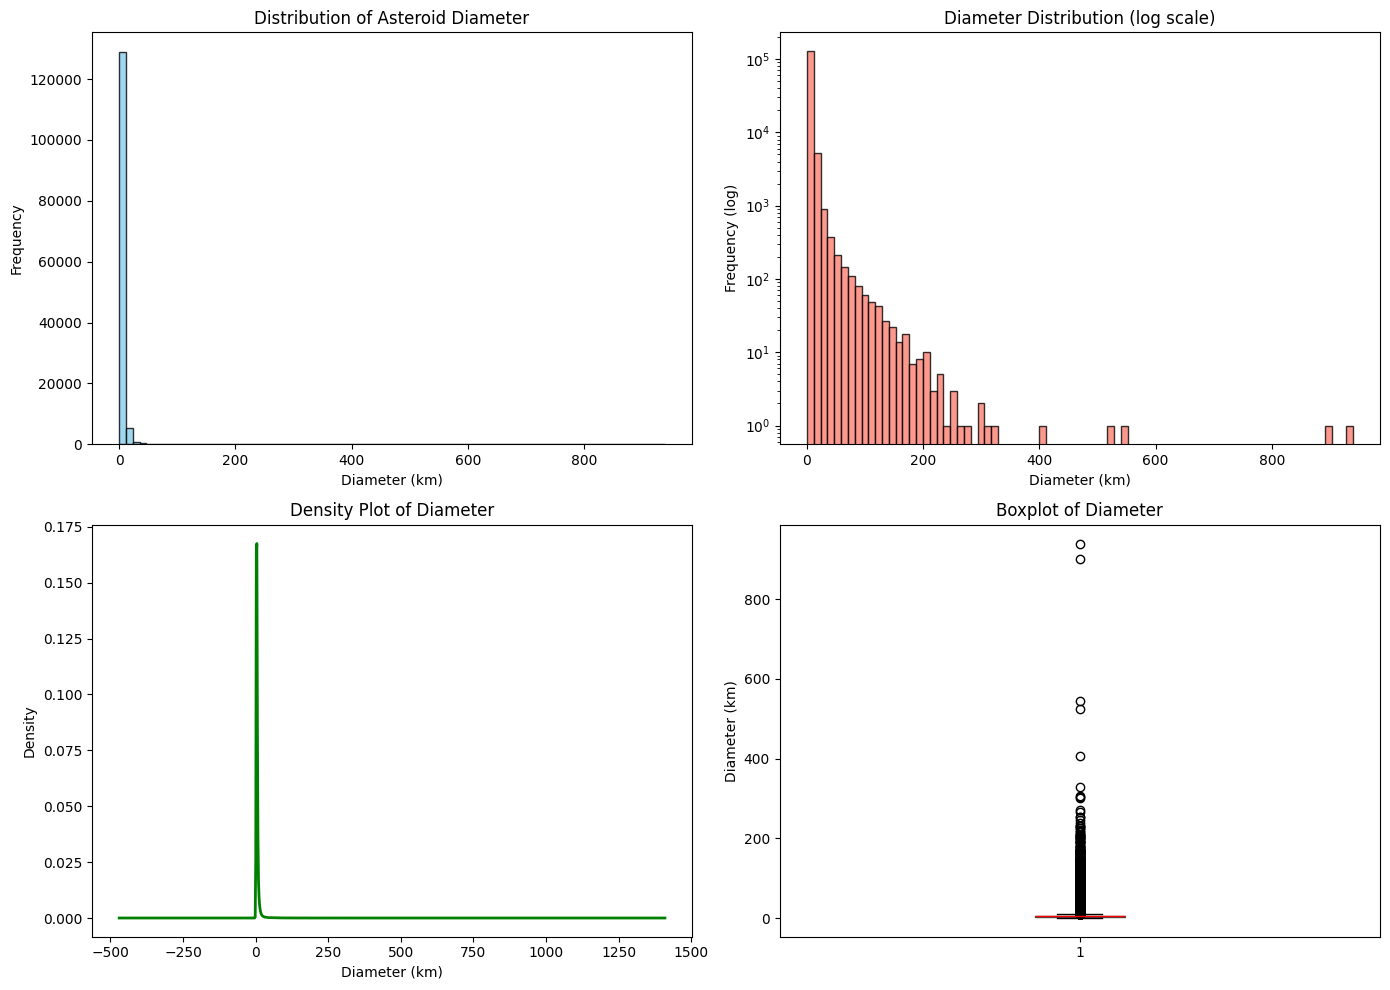

In [77]:
# Diameter distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_diameter['diameter'], bins=80, edgecolor='black', color='skyblue', alpha=0.8)
axes[0, 0].set_title('Distribution of Asteroid Diameter')
axes[0, 0].set_xlabel('Diameter (km)')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df_diameter['diameter'], bins=80, edgecolor='black', color='salmon', alpha=0.8)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Diameter Distribution (log scale)')
axes[0, 1].set_xlabel('Diameter (km)')
axes[0, 1].set_ylabel('Frequency (log)')

df_diameter['diameter'].plot(kind='density', ax=axes[1, 0], color='green', lw=2)
axes[1, 0].set_title('Density Plot of Diameter')
axes[1, 0].set_xlabel('Diameter (km)')
axes[1, 0].set_ylabel('Density')

axes[1, 1].boxplot(df_diameter['diameter'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red'))
axes[1, 1].set_title('Boxplot of Diameter')
axes[1, 1].set_ylabel('Diameter (km)')

plt.tight_layout()
plt.show()

In [78]:
# Key features to analyze with diameter
selected_features = ['H', 'albedo', 'a', 'e', 'i', 'diameter']
subset = df_asteroid[selected_features].dropna()

subset.head()

,H,albedo,a,e,i,diameter
0,3.40,0.0900,2.769165,0.076009,10.594067,939.400
1,4.20,0.1010,2.773841,0.229972,34.832932,545.000
2,5.33,0.2140,2.668285,0.256936,12.991043,246.596
3,3.00,0.4228,2.361418,0.088721,7.141771,525.400
4,6.90,0.2740,2.574037,0.190913,5.367427,106.699


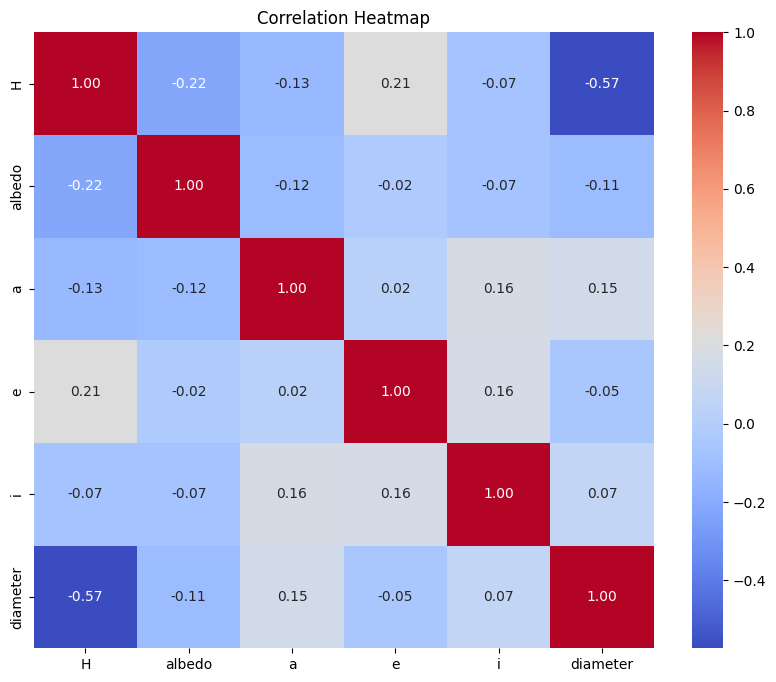

In [79]:
# Correlation heatmap
corr = subset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

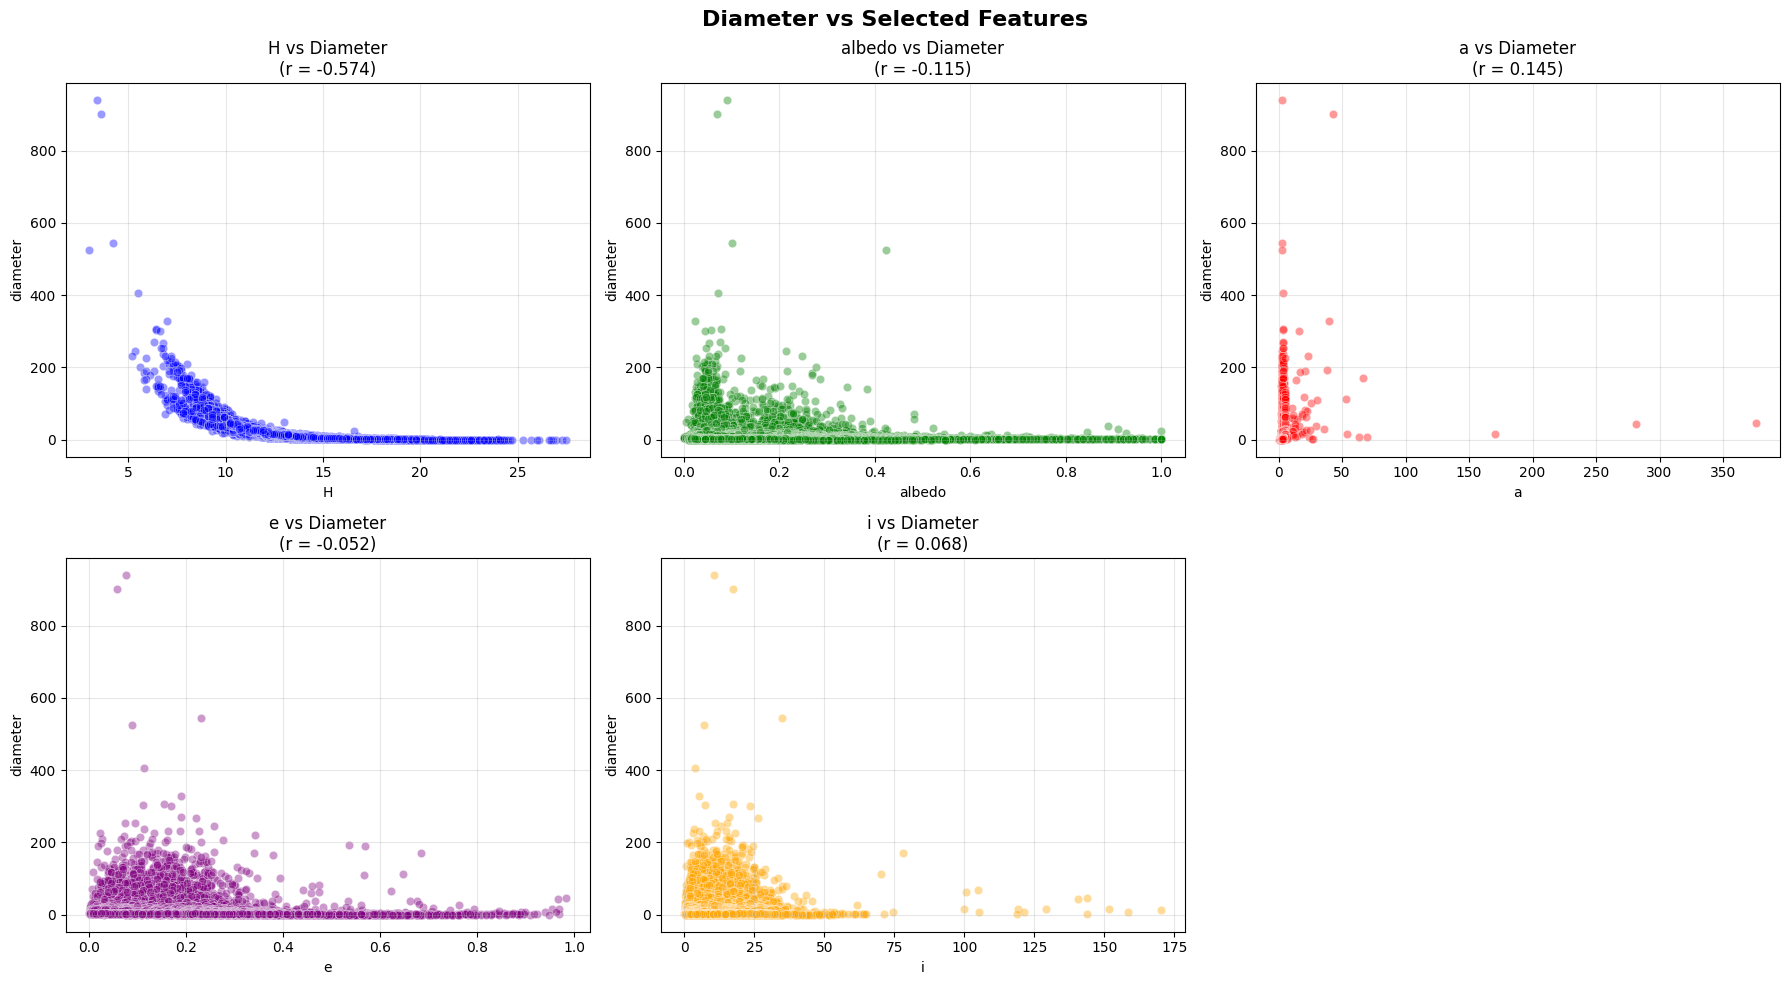

In [80]:
# Scatterplots: diameter vs selected features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Diameter vs Selected Features', fontsize=16, fontweight='bold')

feature_list = ['H', 'albedo', 'a', 'e', 'i']
colors = ['blue', 'green', 'red', 'purple', 'orange']

for i, feature in enumerate(feature_list):
    row, col = divmod(i, 3)
    ax = axes[row, col]
    sns.scatterplot(data=subset, x=feature, y='diameter', alpha=0.4, color=colors[i], ax=ax)
    corr_val = subset[[feature, 'diameter']].corr().iloc[0, 1]
    ax.set_title(f'{feature} vs Diameter\n(r = {corr_val:.3f})')
    ax.grid(True, alpha=0.3)

# Hide empty subplot if present
if len(feature_list) < 6:
    axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

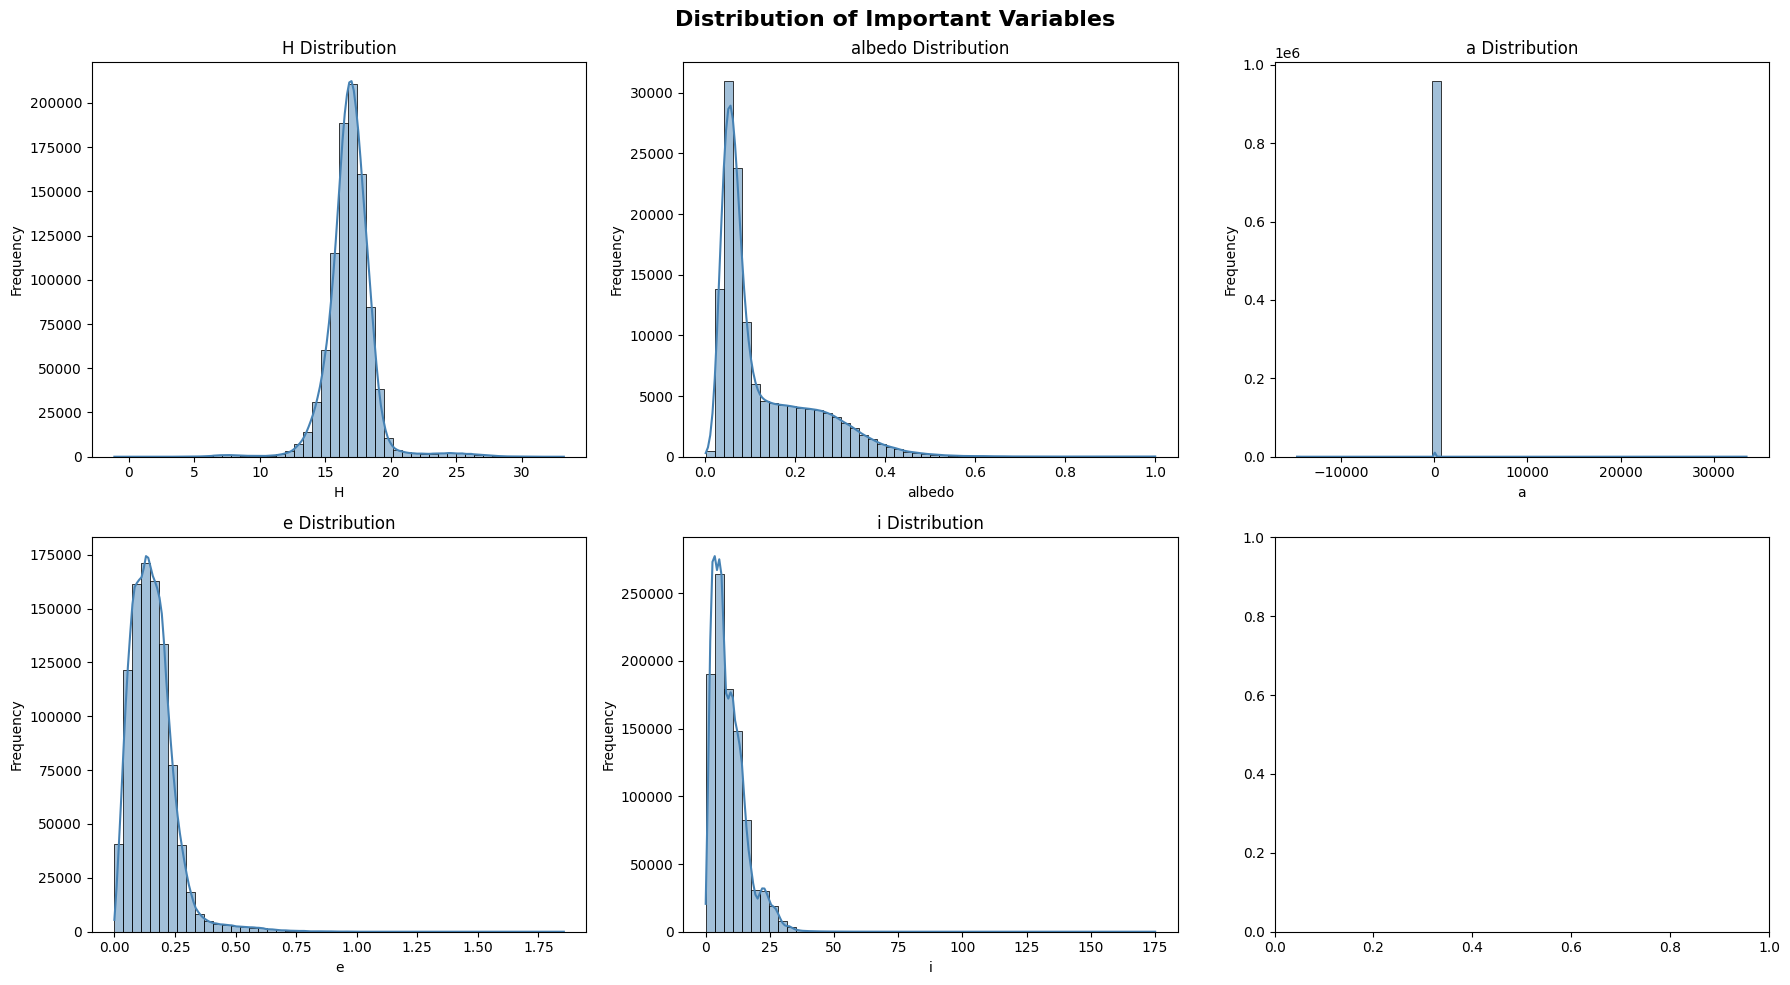

In [81]:
# Distribution of important variables
important_vars = ['H', 'albedo', 'a', 'e', 'i']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Important Variables', fontsize=16, fontweight='bold')

for i, var in enumerate(important_vars):
    row, col = divmod(i, 3)
    sns.histplot(df_asteroid[var].dropna(), bins=50, kde=True, ax=axes[row, col], color='steelblue')
    axes[row, col].set_title(f'{var} Distribution')
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

diameter_category
<1 km          611
1-5 km       89761
5-10 km      35731
10-50 km      9343
50-100 km      523
>100 km        240
Name: count, dtype: int64


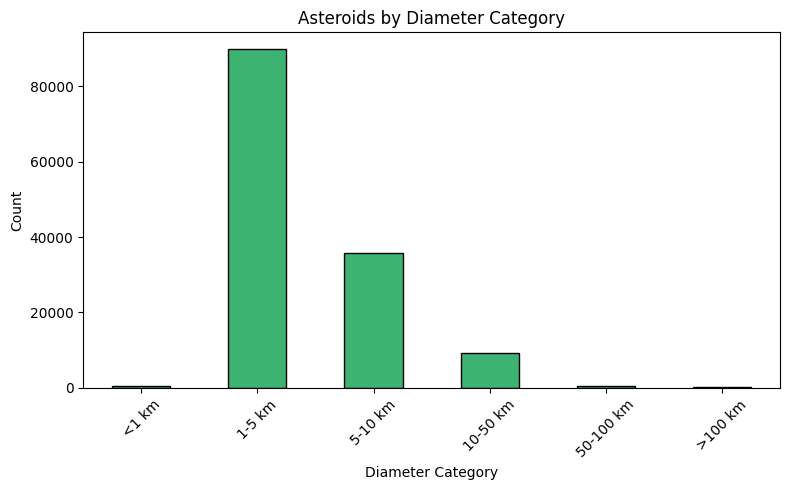

In [82]:
# Optional: diameter categories
bins = [0, 1, 5, 10, 50, 100, 1000]
labels = ['<1 km', '1-5 km', '5-10 km', '10-50 km', '50-100 km', '>100 km']

df_diameter['diameter_category'] = pd.cut(df_diameter['diameter'], bins=bins, labels=labels, right=False)

category_counts = df_diameter['diameter_category'].value_counts().sort_index()
print(category_counts)

plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Asteroids by Diameter Category')
plt.xlabel('Diameter Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [83]:
# Summary of correlations with diameter
corr_with_diameter = subset.corr()['diameter'].drop('diameter').sort_values(ascending=False)
print(corr_with_diameter)

a         0.145010
i         0.067686
e        -0.052382
albedo   -0.114903
H        -0.573641
Name: diameter, dtype: float64


# Task 1

In [84]:
## Question 1

# No, based on the visuals, the target variable “diameter” is not normally distributed.
# It is strongly right-skewed, and a log transformation would make it
# much closer to a normal distribution for modeling purposes.

# The clearest visual evidence is the histogram and Q-Q plot:

# The diameter histogram is strongly right-skewed: most asteroid diameters are concentrated at small values,
# while a long tail extends toward very large diameters.

# The Q-Q plot bends away from the straight reference line, especially in the tails. For a normal distribution,
# the points should stay close to that line.

# The density curve is asymmetric and heavier on the right side, which is another sign of skewness.

# The boxplot shows many outliers above the upper whisker, which is typical of a skewed distribution rather than a normal one.

# This pattern is expected in asteroid datasets because there are many small asteroids and only a few unusually large ones.
# In other words, a small number of very large diameters creates a long right tail.

In [85]:
# Question 2

# The strongest relationships with asteroid diameter appear to be:

# Absolute magnitude (H): strong negative relationship—larger asteroids generally have lower H values.
# Albedo: a weaker relationship compared with H.
# Orbital features such as semi-major axis (a), eccentricity (e), and inclination (i)
# show relatively weak relationships with diameter.

In [86]:
# Question 3

# Absolute magnitude (H) remains the strongest predictor, which is fundamentally a
# brightness measurement—more directly related to the physical size and reflectivity of the asteroid.

# Orbital characteristics might influence asteroid size for these reasons:

# Collisional History: Asteroids in different orbital regions experience different collision frequencies and impacts.
# Asteroids in crowded regions (like the inner asteroid belt) undergo more collisions,
# which can fragment larger asteroids into smaller pieces over time.

# Dynamical Stability: Stable orbits allow asteroids to survive longer without being ejected or colliding.
# Asteroids in unstable orbits may be destroyed, leaving only smaller remnants or newly formed small asteroids.

# Migration and Orbital Resonances: Orbital resonances with planets can cause asteroids to migrate into different regions.
# Some regions may be more conducive to retaining larger bodies, while others may preferentially contain smaller asteroids.

# Formation Location: Asteroids formed at different distances from the Sun had different formation conditions
# (temperature, material composition, density). These formation locations correlate with current orbital characteristics,
# which may influence typical asteroid sizes in those regions.

# Compositional Variation by Orbit: Different orbital zones contain asteroids of different compositions
# (C-type, S-type, M-type, etc.). Some compositions may naturally produce larger bodies, or larger bodies of
# certain compositions may survive longer in specific orbits.

# Gravitational Interactions: Close encounters with planets or larger asteroids can alter orbits.
# The orbital characteristics reflect the dynamical history, which is tied to size distribution outcomes.

# However, the weak correlation observed in your data suggests these orbital factors are not primary drivers of asteroid size.

# Data Preprocessing & Feature Engineering

In [87]:
# Features: orbital and physical properties
# Target: diameter

# Exclude identifier columns and other non-feature columns along with highly missing value columns
# 'neo', 'pha', and 'class' are intended as features after encoding, so they are not in this exclude list.
exclude_cols = ['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix',
                     'orbit_id', 'equinox', 'epoch_cal','albedo',
    'diameter_sigma']

In [88]:
# Encode neo and pha (binary Y/N columns)
df_asteroid['neo'] = df_asteroid['neo'].map({'Y': 1, 'N': 0})
df_asteroid['pha'] = df_asteroid['pha'].map({'Y': 1, 'N': 0})

In [89]:
# One-hot encode class

if 'class' in df_asteroid.columns:
    df_asteroid = pd.get_dummies(
        df_asteroid,
        columns=['class'],
        drop_first=True,
        dtype=int
    )

In [90]:
# First, check what columns exist
print(df_asteroid.columns)

# Check which columns are categorical (object type)
print(df_asteroid.dtypes)

# See unique values in categorical columns
print(df_asteroid.select_dtypes(include='object').head())

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms',
       'class_APO', 'class_AST', 'class_ATE', 'class_CEN', 'class_HYA',
       'class_IEO', 'class_IMB', 'class_MBA', 'class_MCA', 'class_OMB',
       'class_TJN', 'class_TNO'],
      dtype='object')
id                 object
spkid               int64
full_name          object
pdes               object
name               object
prefix             object
neo               float64
pha               float64
H                 float64
diameter          float64
albedo            float64
diameter_sigma    float64
orbit_id           object
epoch           

In [91]:
# Drop excluded columns from dataframe

df_asteroid.drop(columns=exclude_cols, inplace=True)

In [92]:
## Separating Numerical and Categorical data
numeric_cols = df_asteroid.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_asteroid.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# show dtypes for manual checking
print("\nColumn dtypes:\n", df_asteroid.dtypes)

Numeric columns: ['neo', 'pha', 'H', 'diameter', 'epoch', 'epoch_mjd', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms', 'class_APO', 'class_AST', 'class_ATE', 'class_CEN', 'class_HYA', 'class_IEO', 'class_IMB', 'class_MBA', 'class_MCA', 'class_OMB', 'class_TJN', 'class_TNO']
Categorical columns: []

Column dtypes:
 neo          float64
pha          float64
H            float64
diameter     float64
epoch        float64
epoch_mjd      int64
e            float64
a            float64
q            float64
i            float64
om           float64
w            float64
ma           float64
ad           float64
n            float64
tp           float64
tp_cal       float64
per          float64
per_y        float64
moid         float64
moid_ld      float64
sigma_e      float64
sigma_a      float64
sigma_q      flo

In [93]:
df_asteroid.head(5)

,neo,pha,H,diameter,epoch,epoch_mjd,e,a,q,i,...,class_ATE,class_CEN,class_HYA,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,0.0,0.0,3.40,939.400,2458600.5,58600,0.076009,2.769165,2.558684,10.594067,...,0,0,0,0,0,1,0,0,0,0
1,0.0,0.0,4.20,545.000,2459000.5,59000,0.229972,2.773841,2.135935,34.832932,...,0,0,0,0,0,1,0,0,0,0
2,0.0,0.0,5.33,246.596,2459000.5,59000,0.256936,2.668285,1.982706,12.991043,...,0,0,0,0,0,1,0,0,0,0
3,0.0,0.0,3.00,525.400,2458600.5,58600,0.088721,2.361418,2.151909,7.141771,...,0,0,0,0,0,1,0,0,0,0
4,0.0,0.0,6.90,106.699,2459000.5,59000,0.190913,2.574037,2.082619,5.367427,...,0,0,0,0,0,1,0,0,0,0


In [94]:
# Store original number of rows
original_rows = len(df_asteroid)

# Calculate cleaning statistics
cleaned_rows = len(df_asteroid)
rows_removed = original_rows - cleaned_rows
data_retention = (cleaned_rows / original_rows) * 100

print(f"Original dataset: {original_rows:,} rows")
print(f"After removing missing diameter: {cleaned_rows:,} rows")
print(f"Rows removed: {rows_removed:,}")
print(f"Data retention: {data_retention:.2f}%")

Original dataset: 958,524 rows
After removing missing diameter: 958,524 rows
Rows removed: 0
Data retention: 100.00%


# Train-Test Split

In [95]:
# Missing Values of target handling

df_asteroid = df_asteroid.dropna(subset=['diameter'])
print("Shape after removing missing target:", df_asteroid.shape)

Shape after removing missing target: (136209, 45)


In [96]:
X = df_asteroid.drop(columns=['diameter'])      # Feature
y = df_asteroid['diameter']                     # Target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (136209, 44)
y shape: (136209,)


In [97]:
# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Training: (108967, 44)
Testing : (27242, 44)
y_train: (108967,)
y_test : (27242,)


In [98]:
# Handling the missing values

numeric_cols = X_train.select_dtypes(
    include=[np.number]
).columns

imputer = SimpleImputer(strategy='median')

X_train[numeric_cols] = imputer.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = imputer.transform(
    X_test[numeric_cols]
)

In [99]:

# Verifying the missing values

print("Missing values in X_train:")
print(X_train.isna().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isna().sum().sum())

print("Missing target values:")
print(y_train.isna().sum(), y_test.isna().sum())

Missing values in X_train:
0

Missing values in X_test:
0
Missing target values:
0 0


## Scaling

In [100]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [101]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [102]:
# Saving the preprocessing object

joblib.dump(imputer, 'asteroid_imputer.pkl')
joblib.dump(scaler, 'asteroid_scaler.pkl')

print("Imputer and scaler saved.")

Imputer and scaler saved.


In [103]:
# Calculate feature importance

print("="*70)
print("STEP 5: Feature Importance (Random Forest)")
print("="*70)

sample_size = min(10000, len(X_train))

X_sample = X_train.sample(
    n=sample_size,
    random_state=42
)

y_sample = y_train.loc[X_sample.index]

rf_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_sample, y_sample)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
for idx, row in feature_importance.iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"{row['feature']:25s}: {row['importance']:7.4f} {bar}")

print("\nTop 10 Most Important Features:")
for i, (idx, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']:25s} (importance: {row['importance']:.4f})")

STEP 5: Feature Importance (Random Forest)

Feature Importance Ranking:
H                        :  0.7617 ████████████████████████████████████████████████████████████████████████████
n                        :  0.0426 ████
sigma_e                  :  0.0344 ███
sigma_i                  :  0.0257 ██
sigma_a                  :  0.0245 ██
sigma_w                  :  0.0157 █
sigma_n                  :  0.0123 █
ad                       :  0.0114 █
sigma_q                  :  0.0079 
sigma_ad                 :  0.0073 
epoch_mjd                :  0.0070 
ma                       :  0.0063 
rms                      :  0.0042 
w                        :  0.0038 
per                      :  0.0034 
a                        :  0.0032 
per_y                    :  0.0031 
om                       :  0.0030 
moid_ld                  :  0.0028 
sigma_om                 :  0.0025 
tp                       :  0.0025 
i                        :  0.0024 
q                        :  0.0023 
e         

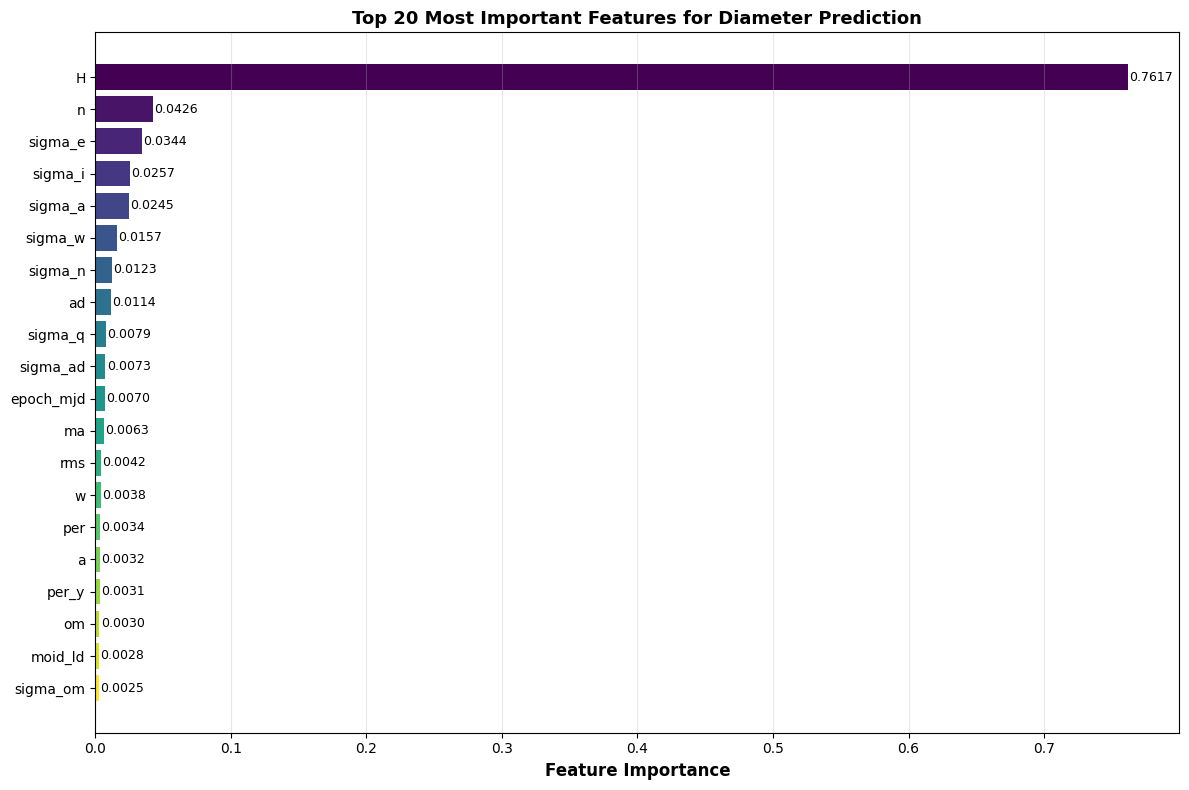

In [104]:
# Visualize feature importance

fig, ax = plt.subplots(figsize=(12, 8))

top_20 = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_20)))
ax.barh(range(len(top_20)), top_20['importance'].values, color=colors)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'].values, fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Important Features for Diameter Prediction',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(top_20['importance'].values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [105]:
# Task 2

In [106]:
# Question 1

# Feature scaling is important for DNNs because:

# Faster convergence - Gradient descent updates weights more efficiently
# Prevents vanishing/exploding gradients - Keeps values in safe numerical ranges
# Equal feature contribution - Large-range features don't dominate learning
# One learning rate for all features - Simplifies hyperparameter tuning
# Better weight initialization - Aligns with how weights are initialized
# Fairer regularization - L1/L2 penalties applied equally across features

In [107]:
# Question 2

# Features Removed:

# Identifiers (7 columns): id, spkid, full_name, pdes, name, prefix, orbit_id

# Why: Non-predictive metadata, no relationship to diameter
# Target Variable (1 column): diameter

# Why: Cannot use target as input feature
# Measurement Uncertainty (1 column): diameter_sigma

# Why: Correlates with data availability, not actual diameter; adds noise
# Redundant Time Variables (3 columns): epoch, epoch_cal, tp_cal

# Why: Epoch_mjd kept; these are duplicate time representations
# Derived Orbital Elements (2 columns): per, per_y

# Why: Orbital period is derived from semi-major axis (a); redundant
# Measurement Noise/Sigma Columns (11 columns): sigma_e, sigma_a, sigma_q,
# sigma_i, sigma_om, sigma_w, sigma_ma, sigma_ad, sigma_n, sigma_tp, sigma_per

# Why: Measurement errors, not predictive features; add noise without
# predictive power
# Total Removed: 25 columns

# Retained: 32 features (H, albedo, orbital elements, neo, pha, moid,
# class encodings, rms, equinox)

In [108]:
# Qusetion 3

# How Highly Correlated Features Affect Model Learning:

# Multicollinearity Issues

# Weights become unstable and unreliable
# Small changes in data cause large weight swings
# Model becomes fragile and doesn't generalize well
# Redundant Information

# Same information encoded twice wastes model capacity
# Neural network uses extra layers/neurons for correlated features
# Inefficient use of computational resources
# Difficulty in Feature Importance

# Can't determine which correlated feature truly drives predictions
# Feature importance scores become ambiguous
# Hard to interpret model decisions
# Slower Convergence

# Gradient descent takes longer to optimize weights
# Creates a flat valley in the loss surface
# Training becomes slower and less stable
# Overfitting Risk

# Model fits noise in one correlated feature
# Poor generalization to new data
# Validation performance drops
# Regularization Less Effective

# L1/L2 penalties can't efficiently reduce correlated features
# Regularization may remove useful information instead
# Example: If you have both a (semi-major axis) and per (orbital period) —
# they're mathematically related (Kepler's law). Using both is redundant.

## DNN

In [109]:
# HYPERPARAMETERS

lr = 0.001  # Learning rate
batch_size = 32  # Batch size
num_neurons = 128  # Number of neurons
dropout_rate = 0.3  # Dropout rate
epochs = 5

print("\n" + "="*70)
print("HYPERPARAMETERS")
print("="*70)
print(f"Learning Rate: {lr}")
print(f"Batch Size: {batch_size}")
print(f"Number of Neurons: {num_neurons}")
print(f"Dropout Rate: {dropout_rate}")


HYPERPARAMETERS
Learning Rate: 0.001
Batch Size: 32
Number of Neurons: 128
Dropout Rate: 0.3


In [110]:
# BUILD DNN MODEL

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(32, activation='relu'),

    layers.Dense(1, activation='linear')
])

In [111]:
# Compile model

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='mse',
    metrics=['mae', 'mse']
)

print("\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70)
model.summary()


MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,513 (64.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [112]:
# TRAIN MODEL

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [113]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Training completed!")

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 87.8384 - mae: 3.0441 - mse: 87.8384 - val_loss: 4030.7627 - val_mae: 62.8959 - val_mse: 4030.7627 - learning_rate: 0.0010
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 82.0813 - mae: 2.8134 - mse: 82.0813 - val_loss: 45846.1836 - val_mae: 213.9534 - val_mse: 45846.1836 - learning_rate: 0.0010
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 81.1999 - mae: 2.7815 - mse: 81.1999 - val_loss: 9284.6035 - val_mae: 96.1295 - val_mse: 9284.6035 - learning_rate: 0.0010
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 81.0585 - mae: 2.7727 - mse: 81.0585 - val_loss: 1724.8464 - val_mae: 41.1574 - val_mse: 1724.8464 - learning_rate: 0.0010
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 80.7865 - mae: 2.7651 - mse: 80.7865 - val_loss: 20425.6328 - val_mae: 142.6478 - val_mse: 20425.6328 - learning_rate: 0.0010
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 79.7733 - mae: 2.8

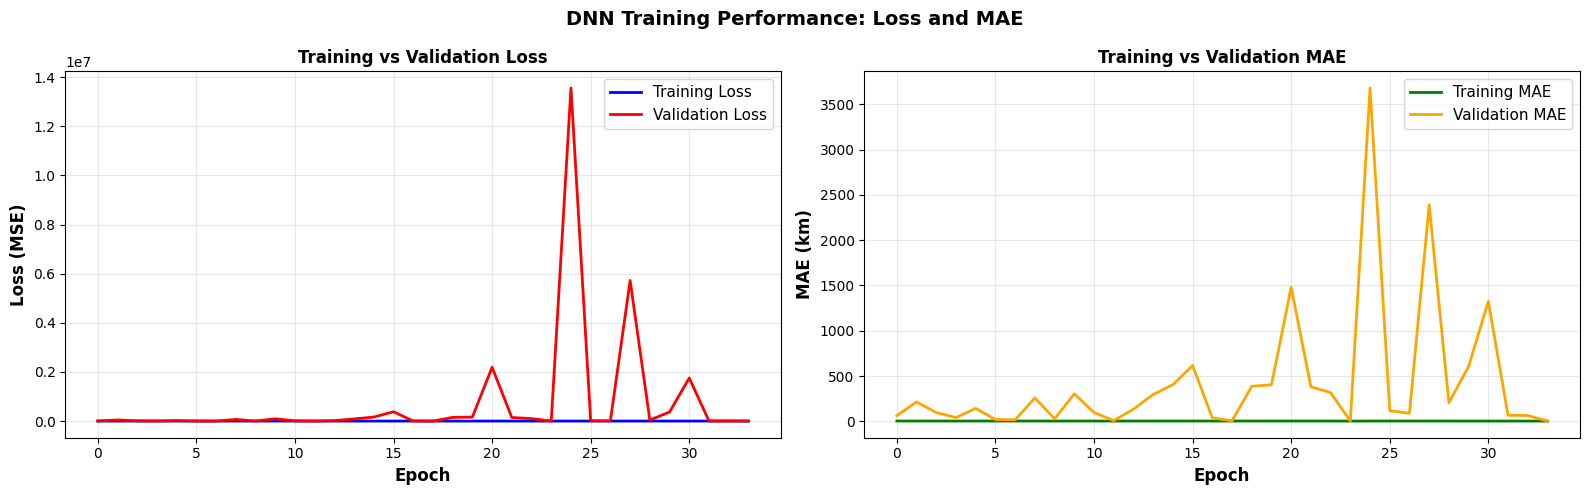

In [114]:
# PLOT TRAINING HISTORY
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DNN Training Performance: Loss and MAE', fontsize=14, fontweight='bold')

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2, color='green')
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (km)', fontsize=12, fontweight='bold')
axes[1].set_title('Training vs Validation MAE', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [115]:
# Task 3

In [116]:
# Question 1

# In regression, we use linear activation in the output layer because we need to predict a continuous numerical value.

# It allows the model to output any real-valued number.

# Regression → Linear

In [117]:
# Question 2

# Hyperparameters can have a great impact on model performance because they control how the model learns.

# Learning rate → controls how quickly the model learns.

# Number of layers/neurons → controls model complexity.

# Batch size → affects learning stability and speed.

# Number of trees in Random Forest → affects prediction quality and overfitting.

# Max depth → controls how complex the model can become.

# If the hyperparameters are poorly chosen, the model may underfit or overfit, giving poor results.

# Hyperparameters decide how the model learns, so changing them can significantly change the final performance.

In [118]:
# Question 3

# If training loss keeps decreasing while validation loss remains higher or starts increasing, the model is overfitting.

# If both training and validation loss are high and close together, the model is underfitting.

# If both losses decrease and become close to each other, the model is learning well without significant overfitting.

# Model Evaluation & Error Analysis

In [119]:
y_train_pred = model.predict(
    X_train_scaled,
    verbose=0
).flatten()

y_test_pred = model.predict(
    X_test_scaled,
    verbose=0
).flatten()

In [122]:
# Evaluate the model

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

print("TRAINING RESULTS")
print("----------------")
print("MSE :", train_mse)
print("MAE :", train_mae)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nTEST RESULTS")
print("----------------")
print("MSE :", test_mse)
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

TRAINING RESULTS
----------------
MSE : 106376309.58634172
MAE : 10242.943662870885
RMSE: 10313.889159106846
R²  : -1239511.1298988461

TEST RESULTS
----------------
MSE : 106594973.14517573
MAE : 10248.44143364003
RMSE: 10324.484158793393
R²  : -1056649.9400752415


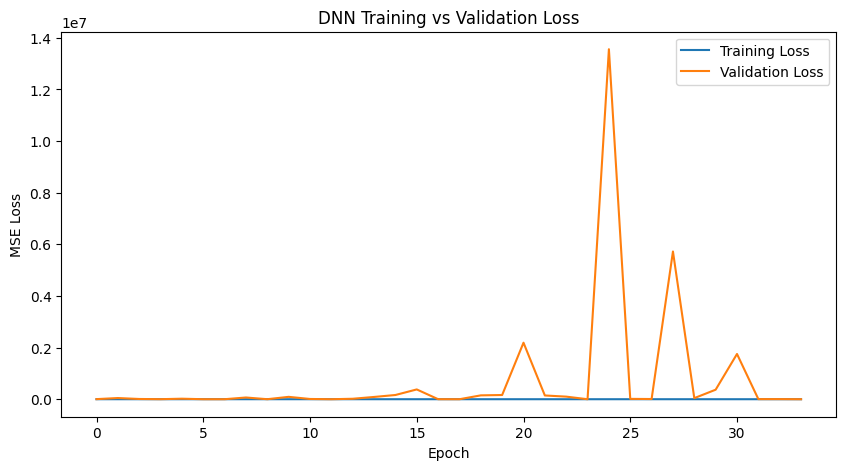

In [124]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DNN Training vs Validation Loss')

plt.legend()
plt.show()

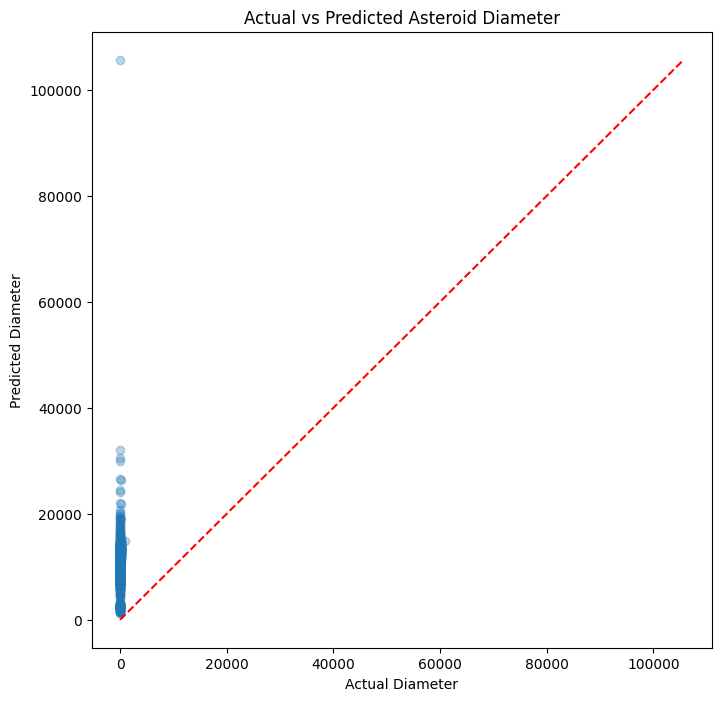

In [129]:

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.3
)

plt.xlabel('Actual Diameter')
plt.ylabel('Predicted Diameter')
plt.title('Actual vs Predicted Asteroid Diameter')

# Perfect prediction line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.show()

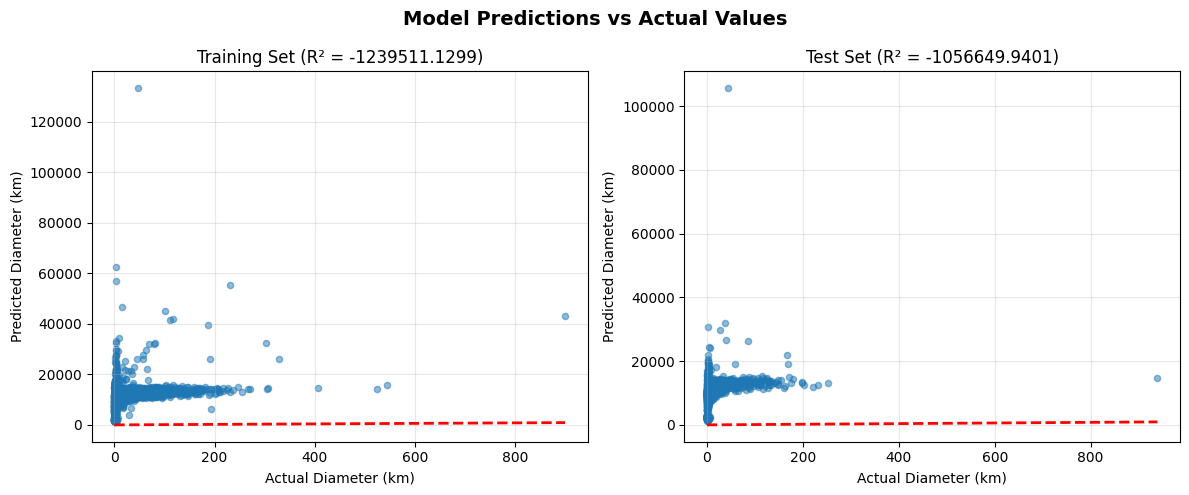

In [131]:
# PLOT PREDICTIONS VS ACTUAL

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    'Model Predictions vs Actual Values',
    fontsize=14,
    fontweight='bold'
)

# Training
axes[0].scatter(
    y_train,
    y_train_pred,
    alpha=0.5,
    s=20
)

axes[0].plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--',
    lw=2
)

axes[0].set_xlabel('Actual Diameter (km)')
axes[0].set_ylabel('Predicted Diameter (km)')
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})')
axes[0].grid(alpha=0.3)

# Test
axes[1].scatter(
    y_test,
    y_test_pred,
    alpha=0.5,
    s=20
)

axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)

axes[1].set_xlabel('Actual Diameter (km)')
axes[1].set_ylabel('Predicted Diameter (km)')
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [132]:
# SUMMARY

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nHyperparameters Used:")
print(f"  Learning Rate: {lr}")
print(f"  Batch Size: {batch_size}")
print(f"  Number of Neurons: {num_neurons}")
print(f"  Dropout Rate: {dropout_rate}")

print(f"\nModel Architecture:")
print(f"  Input: {X_train_scaled.shape[1]} features")
print(f"  Hidden: 3 × {num_neurons} neurons with ReLU + {dropout_rate*100}% Dropout")
print(f"  Output: 1 neuron (Linear)")
print(f"  Total Parameters: {model.count_params():,}")

print(f"\nBest Performance:")
print(f"  Best Val MSE: {min(history.history['val_loss']):.4f}")
print(f"  Best Val MAE: {min(history.history['val_mae']):.4f} km")

print(f"\nTest Set Results:")
print(f"  RMSE: {test_rmse:.4f} km")
print(f"  MAE:  {test_mae:.4f} km")
print(f"  R²:   {test_r2:.4f}")

print("="*70)


FINAL SUMMARY

Hyperparameters Used:
  Learning Rate: 0.001
  Batch Size: 32
  Number of Neurons: 128
  Dropout Rate: 0.3

Model Architecture:
  Input: 44 features
  Hidden: 3 × 128 neurons with ReLU + 30.0% Dropout
  Output: 1 neuron (Linear)
  Total Parameters: 16,897

Best Performance:
  Best Val MSE: 73.9240
  Best Val MAE: 3.2550 km

Test Set Results:
  RMSE: 10324.4842 km
  MAE:  10248.4414 km
  R²:   -1056649.9401


In [134]:
# Save the model

os.makedirs('models', exist_ok=True)
model.save(
    'models/asteroid_diameter_model.keras'
)

joblib.dump(
    imputer,
    'models/asteroid_imputer.pkl'
)

joblib.dump(
    scaler,
    'models/asteroid_scaler.pkl'
)

joblib.dump(
    X_train.columns.tolist(),
    'models/asteroid_features.pkl'
)

print("All model files saved successfully.")

All model files saved successfully.


In [135]:
# Task 4

In [137]:
# Question 1

# For asteroid diameter prediction, the best evaluation metrics are
# MAE, RMSE, and R² because this is a regression problem.

# MAE and RMSE are suitable because asteroid diameter is a continuous value and
# these metrics directly measure prediction error.
# RMSE is particularly useful for identifying large errors, while
# R² indicates how well the model explains the target variation.

In [138]:
# Question 2

# The residuals should ideally be randomly scattered around zero.
# If the plot shows a fairly random distribution with no clear curve or pattern, the model is capturing the main relationship reasonably well.
# However, a few points with very large positive or negative residuals indicate outliers or asteroid cases that the model predicts poorly.

# Very small or very large asteroids can be more difficult to predict accurately,
# especially when their available features are incomplete or unusual.
# The difficult cases are generally those with extreme diameter values or unusual feature combinations, which tend to produce larger residuals.

In [140]:
# Task 5

In [139]:
# Question 1

# The application can assist astronomers by rapidly estimating asteroid diameters from available observational and orbital data.
# It can process large asteroid catalogs, flag objects with uncertain predictions, and help prioritize targets for further observation.
# This makes it a decision-support tool for asteroid monitoring rather than a replacement for professional astronomical measurements.

In [141]:
# Question 2

# The predicted diameter should be treated as an estimate, not an exact measurement.
# Accuracy depends on the quality and range of the input data and the similarity of new asteroids to the training data.
# Unusual objects may have larger errors, so professional astronomical observations should be used for confirmation.